In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("/Users/ellasantos/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
data["TotalCharges"].unique()[:10]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95'], dtype=object)

In [14]:
data["Churn"].value_counts(normalize=True)
# Dataset is imbalanced, significantly more non churn customers meaning

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

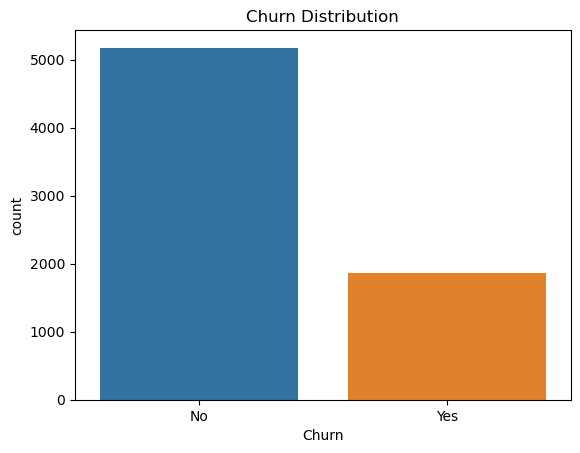

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

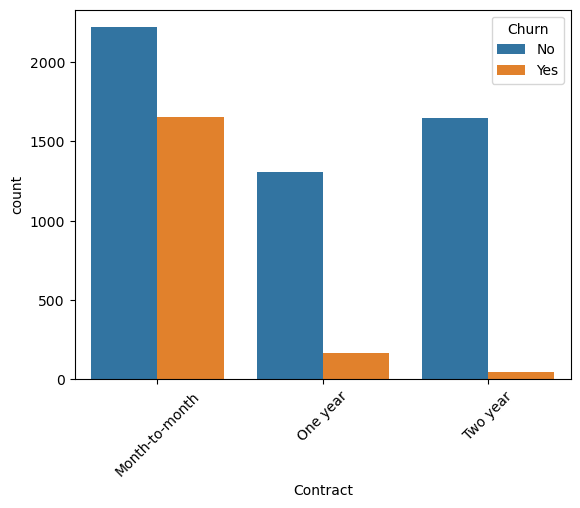

In [17]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.xticks(rotation=45)
plt.show()

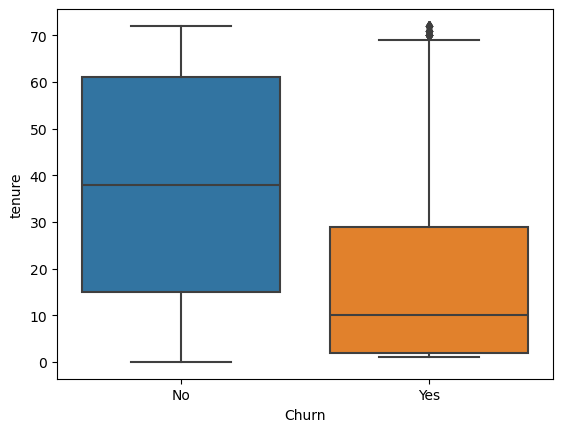

In [18]:
sns.boxplot(x="Churn", y="tenure", data=data)
plt.show()

Customers who churn tend tgo leave early in their life cycle, suggesting that retention efforts should focus on the first few months. 

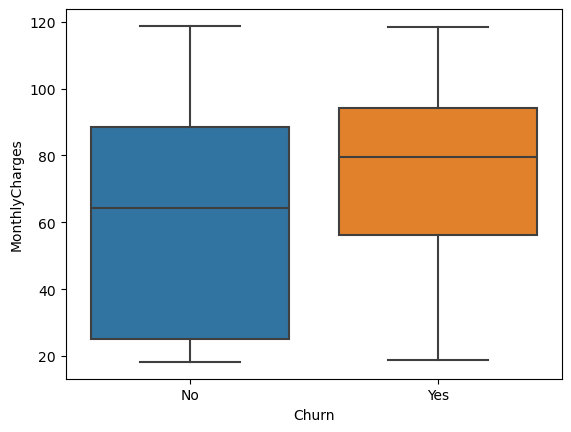

In [20]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.show()

Higher monthly charges are more likely to churn, suggesting price senstivity or perceived lack of value. 

Customers with short tenure and high monthly charges represent the highest churn risk segment, indicating that early-stage pricing or onboarding experience may be key drivers of churn.

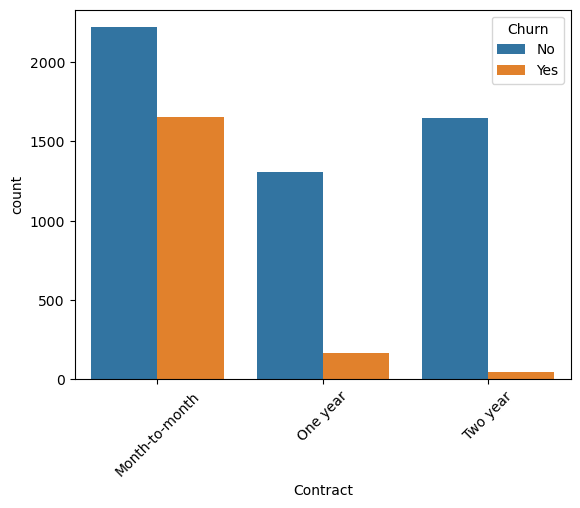

In [22]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.xticks(rotation=45)
plt.show()

In [15]:
data = data.drop("customerID", axis=1)

In [16]:
data.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
data = pd.get_dummies(data, drop_first=True)

Categorical variables were encoded using one-hot encoding to allow machine learning models to interpret non-numeric features.

In [18]:
X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

In [19]:
data.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic',
       ...
       'TotalCharges_996.45', 'TotalCharges_996.85', 'TotalCharges_996.95',
       'TotalCharges_997.65', 'TotalCharges_997.75', 'TotalCharges_998.1',
       'TotalCharges_999.45', 'TotalCharges_999.8', 'TotalCharges_999.9',
       'Churn_Yes'],
      dtype='object', length=6560)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = LogisticRegression(max_iter=1000)

In [23]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [25]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.86      0.91      0.88      1036
        True       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

ROC-AUC: 0.8608265964164088


While the model performs well overall, recall for the churn class is lower, meaning some at-risk customers are not identified. This is a common challenge in imbalanced classification problems.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

       False       0.82      0.92      0.87      1036
        True       0.68      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.70      1409
weighted avg       0.78      0.80      0.78      1409

ROC-AUC: 0.8422565135031623


In [27]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

tenure                            0.114884
MonthlyCharges                    0.091638
PaymentMethod_Electronic check    0.029478
InternetService_Fiber optic       0.024915
OnlineSecurity_Yes                0.024335
Contract_Two year                 0.023617
TechSupport_Yes                   0.021441
PaperlessBilling_Yes              0.019433
Contract_One year                 0.019143
gender_Male                       0.018593
dtype: float64


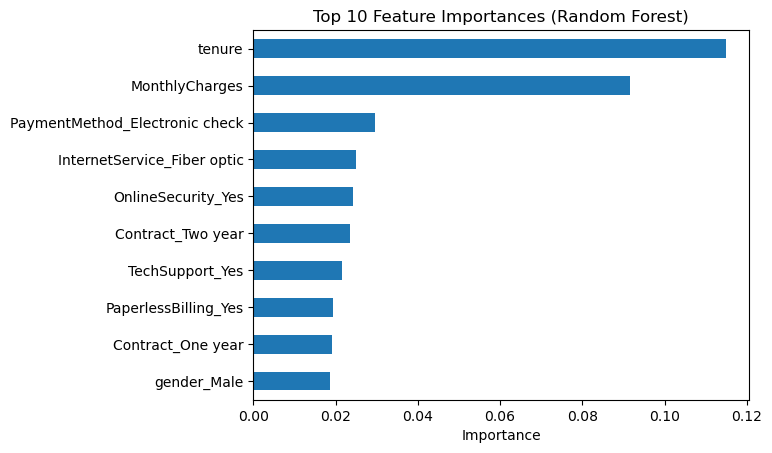

In [28]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure()
top_features.plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

The model identified tenure and monthly charges as the most significant predictors of churn. Customers with shorter tenure were more likely to leave, indicating that early-stage retention is critical. Additionally, higher monthly charges were associated with increased churn, suggesting that pricing and perceived value play a key role in customer decisions.

### These findings suggest that businesses should focus on improving onboarding experiences for new customers and consider pricing strategies or incentives to retain high-paying customers.

In [39]:
data.groupby('Churn_Yes')[['tenure', 'MonthlyCharges']].mean()

,tenure,MonthlyCharges
Churn_Yes,,
False,37.569965,61.265124
True,17.979133,74.441332


Customers who churned had significantly shorter tenure (18 months vs. 38 months) and higher monthly charges (74 vs. 61) compared to retained customers. This suggests that early-stage engagement and pricing strategies are critical factors in improving customer retention.

### I would recommend targeting newer customers with retention incentives and evaluating pricing tiers for high-cost users.

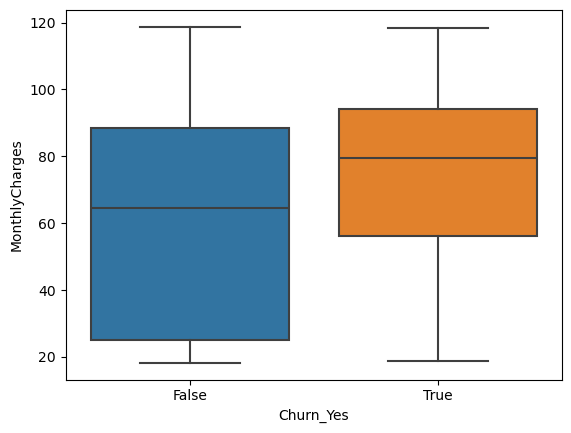

In [36]:
import seaborn as sns

sns.boxplot(x='Churn_Yes', y='MonthlyCharges', data=data)
plt.show()

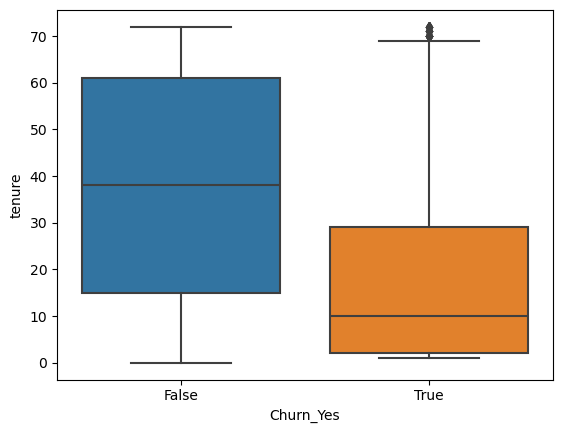

In [38]:
sns.boxplot(x='Churn_Yes', y='tenure', data=data)
plt.show()